In [2]:
# Packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use your own features and labels or grab the csv files with features and labels from today's exercise.

# Load features and labels into dataframes
file_labels = "example_labels.csv"
file_features = "example_features.csv"

df = pd.read_csv("..\..\data\metadata_(for_scores).csv")
#features = pd.read_csv(file_features)

# Check what's inside

df.head()

# Put everything we need together
#df = df.drop(['image_id','seborrheic_keratosis'],axis=1)
#df['area'] = features['area']
#df['perimeter'] = features['perimeter']

# Please remember that area and perimeter alone are often not sufficient for classification.
# When doing your project, you will need other features.

#print(df.head())

,img_id,patient_id,lesion_id,gender,skin_cancer_diagnosis,diagnostic,biopsed,mask_components,melanoma_color_count,melanoma_colors,...,worst_score,Polsby-Popper,convexity_score,lesion_red_share,lesion_green_share,lesion_blue_share,lesion_skin_red_diff,lesion_skin_green_diff,lesion_skin_blue_diff,lesion_skin_rgb_distance
0,PAT_684_1303_368.png,PAT_684,1303,MALE,1,BCC,True,2,1,blue_gray,...,0.228736,0.077357,0.966073,0.385627,0.316149,0.298224,-4.110664,-4.335522,-3.519299,6.933958
1,PAT_842_1606_971.png,PAT_842,1606,FEMALE,1,BCC,True,3,1,blue_gray,...,0.421654,0.074749,0.968111,0.347777,0.307446,0.344777,-8.710226,-22.357424,-8.463104,25.443006
2,PAT_113_172_610.png,PAT_113,172,MALE,1,SCC,True,2,2,"red, blue_gray",...,0.274315,0.078801,0.982251,0.446228,0.283676,0.270096,7.774562,-7.024822,-2.797506,10.845182
3,PAT_1633_2855_460.png,PAT_1633,2855,NaN,0,ACK,False,5,0,NaN,...,0.658751,0.058700,0.981541,0.425111,0.309371,0.265518,16.566090,18.314028,26.037217,35.885591
4,PAT_168_262_74.png,PAT_168,262,MALE,1,BCC,True,1,1,blue_gray,...,0.323160,0.098814,0.964321,0.417867,0.292136,0.289997,-12.708808,-19.862190,-18.049245,29.695044


In [9]:
from sklearn.model_selection import train_test_split

#x = df[['melanoma_color_count','hue_variance', 'saturation_variance', 
#        'value_variance', 'Polsby-Popper', 'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'convexity_score']]
#x = df[['saturation_variance', 'mabrouk_asymmetry_score', 'convexity_score']]

#x = df [['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance',
#       'melanoma_color_count', 'convexity_score', 'avg_asymmetry_score',
#       'lesion_red_share', 'worst_score', 'lesion_skin_green_diff',
#       'lesion_skin_red_diff']]

x = df[['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance',]]
y = df['skin_cancer_diagnosis']

dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0)

train_x, val_x, train_y, val_y = train_test_split(
        dev_x, dev_y, stratify=dev_y, random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=True, with_std=True)

# Fit på træningsdata
scaler.fit(train_x)

# Transformér både train og test area
train_x_scaled = scaler.transform(train_x)
test_x_scaled = scaler.transform(test_x)
val_x_scaled = scaler.transform(val_x)

In [11]:
n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9]

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
auc_train = []
auc_val = []

for n in n_neighbors:
    knn1 = KNeighborsClassifier(n_neighbors=n)
    knn1_trained = knn1.fit(train_x_scaled, np.ravel(train_y))
    train_pred_knn1 = knn1_trained.predict(train_x_scaled)
    val_pred_knn1 = knn1_trained.predict(val_x_scaled)

    auc_train.append(roc_auc_score(train_y, train_pred_knn1))
    auc_val.append(roc_auc_score(val_y, val_pred_knn1))

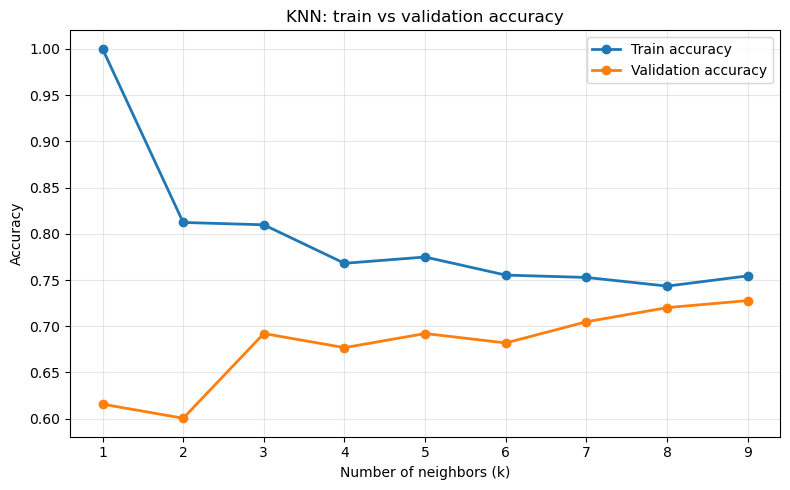

In [13]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

n_neighbors = list(range(1, 10))
train_accs = []
val_accs = []


for n in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(train_x, train_y)

    train_accs.append(knn.score(train_x, train_y))
    val_accs.append(knn.score(val_x, val_y))

plt.figure(figsize=(8, 5))
plt.plot(n_neighbors, train_accs, marker="o", linewidth=2, label="Train accuracy")
plt.plot(n_neighbors, val_accs, marker="o", linewidth=2, label="Validation accuracy")

plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN: train vs validation accuracy")
plt.xticks(n_neighbors)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

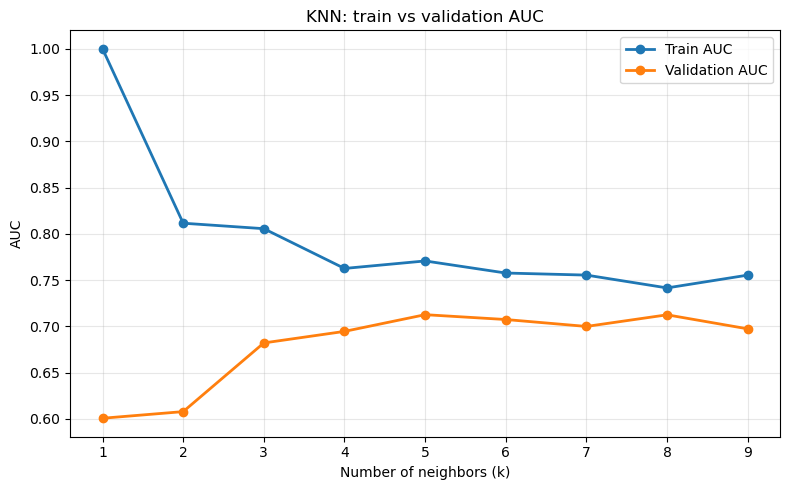

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(n_neighbors, auc_train, "o-", linewidth=2, label="Train AUC")
plt.plot(n_neighbors, auc_val, "o-", linewidth=2, label="Validation AUC")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("AUC")
plt.title("KNN: train vs validation AUC")
plt.xticks(n_neighbors)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()